# BÄKO Potential Analysis: Step-by-Step Manual Execution

This notebook allows you to run the BÄKO potential analysis step by step, with each step in a separate cell. This enables you to review and verify each intermediate result.

## How to Use

1. Run cells sequentially from top to bottom
2. Review outputs after each step
3. Modify parameters in configuration cells as needed
4. Skip optional steps (e.g., PV optimization) if not needed

## Prerequisites

- All dependencies installed (`pixi install`)
- Input data files available
- `config.py` configured with system parameters


## Step 0: Setup and Imports


In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("Imports successful!")


Imports successful!


## Step 0.1: Configuration


In [2]:
# Import configuration
try:
    from config import (
        COOLING_RAMP_SLOPE_IN_K_PER_H,
        WARMING_RAMP_SLOPE_IN_K_PER_H,
        SCHEDULE_TEMP_TYPE_PLUSKUEHLUNG,
        SCHEDULE_TEMP_TYPE_TIEFKUEHLUNG,
        COP,
        POWER_PRICE_IN_EURO_PER_KW,
        LATENT_HEAT_CAPACITY_PLUSKUEHLUNG_J_PER_KG,
        LATENT_HEAT_CAPACITY_TIEFKUEHLUNG_J_PER_KG,
        PCM_MASS_PLUSKUEHLUNG_KG,
        PCM_MASS_TIEFKUEHLUNG_KG,
        PHASE_CHANGE_TEMP_PLUSKUEHLUNG_C,
        PHASE_CHANGE_TEMP_TIEFKUEHLUNG_C,
        LATENT_HEAT_FACTOR_PLUSKUEHLUNG,
        LATENT_HEAT_FACTOR_TIEFKUEHLUNG,
        PV_ARRAYS,
        PV_LOCATION_LAT,
        PV_LOCATION_LON,
        COOLING_SYSTEMS,
        U_VALUE_CALIBRATION_FACTOR,
        U_VALUE_OVERRIDE_W_PER_M2_K,
        VALIDATION_TOLERANCE_PLUSKUEHLUNG_C,
        VALIDATION_TOLERANCE_TIEFKUEHLUNG_C,
    )
    print("Configuration loaded from config.py")
except ImportError as e:
    print(f"Warning: Could not import from config.py: {e}")
    print("Using default values...")
    # Set defaults
    COOLING_RAMP_SLOPE_IN_K_PER_H = -1.0
    WARMING_RAMP_SLOPE_IN_K_PER_H = 2.0
    SCHEDULE_TEMP_TYPE_PLUSKUEHLUNG = "price_like_schedule"
    SCHEDULE_TEMP_TYPE_TIEFKUEHLUNG = "constrained_price_schedule"
    COP = 2.8
    POWER_PRICE_IN_EURO_PER_KW = 100

# Data file paths - MODIFY THESE TO MATCH YOUR SYSTEM
lastgang_path = r"C:\Users\MichaelDotan\Desktop\PotenzialAnalyse\BÄKO\Lastgang_Strom_2024__BÄKO_Bremerhaven (1).xlsx"
cams_path = r"C:\Users\MichaelDotan\Desktop\PotenzialAnalyse\BÄKO\CAMS solar radiation time-series2024.csv"
spot_price_path = None  # Will use API if None

# Analysis period
start_date = pd.Timestamp("2024-05-01 00:00:00")
end_date = pd.Timestamp("2024-05-02 23:59:59")

# Report directory
report_directory = "reports/bako/manual_analysis"
os.makedirs(report_directory, exist_ok=True)

print(f"\nConfiguration:")
print(f"  Analysis period: {start_date.date()} to {end_date.date()}")
print(f"  Report directory: {report_directory}")


Configuration loaded from config.py

Configuration:
  Analysis period: 2024-05-01 to 2024-05-02
  Report directory: reports/bako/manual_analysis


## Step 1: Load Power Consumption Data


In [3]:
# Read Excel file - use 'Zeitreihe' sheet which contains the time series data
excel_file = pd.ExcelFile(lastgang_path)
print(f"Available sheets: {excel_file.sheet_names}")

if 'Zeitreihe' in excel_file.sheet_names:
    df_lastgang = pd.read_excel(excel_file, sheet_name='Zeitreihe')
else:
    # Try first sheet if 'Zeitreihe' doesn't exist
    df_lastgang = pd.read_excel(excel_file, sheet_name=0)

print(f"\nLoaded {len(df_lastgang)} rows")
print(f"Columns: {df_lastgang.columns.tolist()}")
print(f"\nFirst few rows:")
print(df_lastgang.head(30))


Available sheets: ['Datenblatt', 'Zeitreihe', 'Template']

Loaded 35136 rows
Columns: ['Datum', 'Uhrzeit', 'Wert [kW]']

First few rows:
         Datum Uhrzeit  Wert [kW]
0   01.01.2024   00:15   4.413917
1   01.01.2024   00:30   4.260268
2   01.01.2024   00:45   4.113603
3   01.01.2024   01:00   3.980906
4   01.01.2024   01:15   3.862177
5   01.01.2024   01:30   3.750432
6   01.01.2024   01:45   3.638688
7   01.01.2024   02:00   3.526943
8   01.01.2024   02:15   3.401230
9   01.01.2024   02:30   3.275517
10  01.01.2024   02:45   3.156789
11  01.01.2024   03:00   3.065996
12  01.01.2024   03:15   3.003140
13  01.01.2024   03:30   2.968219
14  01.01.2024   03:45   2.947267
15  01.01.2024   04:00   2.933299
16  01.01.2024   04:15   2.926315
17  01.01.2024   04:30   2.919331
18  01.01.2024   04:45   2.919331
19  01.01.2024   05:00   2.933299


In [4]:

# Combine date and time columns
# Handle European date format (DD.MM.YYYY)
# Convert to string first if it's already a datetime/date object
if df_lastgang['Datum'].dtype == 'object':
    # Already strings, parse with explicit format
    df_lastgang['Datum'] = pd.to_datetime(df_lastgang['Datum'], format='%d.%m.%Y', errors='coerce')
else:
    # Might be datetime already, convert to string first then parse
    df_lastgang['Datum'] = pd.to_datetime(df_lastgang['Datum'].astype(str), format='%d.%m.%Y', errors='coerce')

# Check for any NaT (failed parses) and show them
if df_lastgang['Datum'].isna().any():
    failed = df_lastgang[df_lastgang['Datum'].isna()]
    print(f"Warning: {len(failed)} dates failed to parse. First few:")
    print(failed[['Datum']].head(30))

# Parse time column (HH:MM format) and convert to timedelta
# Handle time in HH:MM format by adding :00 to make it HH:MM:SS
df_lastgang['Uhrzeit_parsed'] = pd.to_timedelta(df_lastgang['Uhrzeit'].astype(str) + ':00')
df_lastgang['timestamp'] = df_lastgang['Datum'] + df_lastgang['Uhrzeit_parsed']
df_lastgang = df_lastgang.drop('Uhrzeit_parsed', axis=1)
df_lastgang = df_lastgang.set_index('timestamp')

# Remove duplicate timestamps (keep first occurrence)
df_lastgang = df_lastgang[~df_lastgang.index.duplicated(keep='first')]

# Filter for analysis period (use boolean mask for more flexibility)
df_lastgang = df_lastgang[(df_lastgang.index >= start_date) & (df_lastgang.index <= end_date)]

# Resample to 15-minute intervals
# Drop non-numeric columns (Datum, Uhrzeit) before resampling
df_lastgang = df_lastgang.drop(columns=['Datum', 'Uhrzeit'], errors='ignore')
df_lastgang = df_lastgang.resample('15min').mean()

# Remove any duplicates created during resampling
if df_lastgang.index.duplicated().any():
    print(f"Warning: {df_lastgang.index.duplicated().sum()} duplicate timestamps after resampling, removing...")
    df_lastgang = df_lastgang[~df_lastgang.index.duplicated(keep='first')]

# Rename power column
df_lastgang['Standortverbrauch'] = df_lastgang['Wert [kW]']

print(f"\nAfter processing:")
print(f"  Shape: {df_lastgang.shape}")
print(f"  Time range: {df_lastgang.index.min()} to {df_lastgang.index.max()}")
print(f"  Power range: {df_lastgang['Standortverbrauch'].min():.2f} to {df_lastgang['Standortverbrauch'].max():.2f} kW")
print(f"\nFirst few rows:")
print(df_lastgang[['Standortverbrauch']].head(30))



After processing:
  Shape: (192, 2)
  Time range: 2024-05-01 00:00:00 to 2024-05-02 23:45:00
  Power range: 3.04 to 15.50 kW

First few rows:
                     Standortverbrauch
timestamp                             
2024-05-01 00:00:00           5.286923
2024-05-01 00:15:00           4.770103
2024-05-01 00:30:00           4.644390
2024-05-01 00:45:00           4.511693
2024-05-01 01:00:00           4.372013
2024-05-01 01:15:00           4.211379
2024-05-01 01:30:00           4.043762
2024-05-01 01:45:00           3.876145
2024-05-01 02:00:00           3.722496
2024-05-01 02:15:00           3.575831
2024-05-01 02:30:00           3.457103
2024-05-01 02:45:00           3.352342
2024-05-01 03:00:00           3.261549
2024-05-01 03:15:00           3.191709
2024-05-01 03:30:00           3.135836
2024-05-01 03:45:00           3.093932
2024-05-01 04:00:00           3.065996
2024-05-01 04:15:00           3.045044
2024-05-01 04:30:00           3.038060
2024-05-01 04:45:00           3.045044

## Step 2: Load Solar Radiation Data


In [12]:
from utils.data_processing import read_cams_solar_radiation

# Reload module to get updated function
import importlib
import sys
if 'utils.data_processing' in sys.modules:
    importlib.reload(sys.modules['utils.data_processing'])
    from utils.data_processing import read_cams_solar_radiation

# Load solar radiation data
# Debug: Check raw CSV file first
import pandas as pd
print('\n=== Debugging CSV file ===')
print(f'CSV path: {cams_path}')
# Try reading first few lines to see structure
with open(cams_path, 'r', encoding='utf-8') as f:
    lines = f.readlines()[:30]
    print('\nFirst 30 lines of CSV:')
    for i, line in enumerate(lines):
        print(f'{i}: {line[:100]}...' if len(line) > 100 else f'{i}: {line}')

# Try reading with different separators
try:
    df_test = pd.read_csv(cams_path, sep=';', nrows=50, encoding='utf-8', decimal=',')
    print('\nCSV read with semicolon separator:')
    print(f'Columns: {df_test.columns.tolist()}')
    print(f'Shape: {df_test.shape}')
    print('\nFirst few rows:')
    print(df_test.head(30))
    # Check for 2024-05-01 03:34:00 or similar
    print('\nChecking for May 1st data...')
    may_data = df_test[df_test.iloc[:, 0].astype(str).str.contains('2024-05-01', na=False)]
    if len(may_data) > 0:
        print(f'Found {len(may_data)} rows for May 1st')
        print(may_data.head(30))
except Exception as e:
    print(f'Error reading with semicolon: {e}')
    try:
        df_test = pd.read_csv(cams_path, sep=',', nrows=50, encoding='utf-8')
        print('\nCSV read with comma separator:')
        print(f'Columns: {df_test.columns.tolist()}')
        print(df_test.head(30))
    except Exception as e2:
        print(f'Error reading with comma: {e2}')
# Try to find where actual data starts
with open(cams_path, 'r', encoding='utf-8') as f:
    all_lines = f.readlines()
    print('\n=== Finding data start ===')
    for i, line in enumerate(all_lines[30:50]):  # Check lines 30-50
        if not line.strip().startswith('#'):
            print(f'First non-comment line at index {i+30}: {line[:150]}')
            # Try to parse this as header
            try:
                test_df = pd.read_csv(cams_path, sep=';', skiprows=i+29, nrows=10, encoding='utf-8', decimal=',')
                print(f'\nSuccessfully parsed starting from line {i+30}:')
                print(f'Columns: {test_df.columns.tolist()}')
                print(f'Data types: {test_df.dtypes}')
                print('\nFirst few data rows:')
                print(test_df.head())
                # Check for May 1st data
                first_col = test_df.columns[0]
                may_mask = test_df[first_col].astype(str).str.contains('2024-05-01', na=False)
                if may_mask.any():
                    print(f'\nMay 1st data found:')
                    print(test_df[may_mask].head(30))
                break
            except Exception as e:
                print(f'Error parsing from line {i+30}: {e}')
                continue

# Load solar radiation data from CAMS CSV file
# Note: The function performs two important conversions:
# 1. Units conversion: CAMS CSV provides values in Wh/m² (energy over 15-min period).
#    The function converts to W/m² (power) by dividing by 0.25 hours.
#    Example: 0.1200 Wh/m² → 0.48 W/m² (0.1200 / 0.25 = 0.48)
# 2. Timezone conversion: CAMS data is in UTC. The function converts to Europe/Berlin time
#    (UTC+1 in winter, UTC+2 in summer). This ensures alignment with local power data.
#    Example: 2024-05-01 03:45 UTC → 2024-05-01 05:45 Berlin time (May = UTC+2)
#    The function correctly identifies 'Clear sky GHI' column (not TOA).

df_solar = read_cams_solar_radiation(cams_path)

print(f"Solar data shape: {df_solar.shape}")
print(f"Time range (Berlin time): {df_solar.index.min()} to {df_solar.index.max()}")
print(f"\nFirst few rows (GHI, DNI, DHI in W/m²):")
print(df_solar.head(30))

# Debug: Check GHI value at specific timestamp
check_time = pd.Timestamp('2024-05-01 03:34:00')
if check_time in df_solar.index:
    print(f"\nGHI at {check_time}: {df_solar.loc[check_time, 'GHI']:.2f} W/m²")
else:
    # Find nearest timestamps
    # Find nearest timestamps (handle duplicates)
    # Remove duplicates first for get_indexer
    df_solar_unique = df_solar[~df_solar.index.duplicated(keep='first')]
    nearest_idx = df_solar_unique.index.get_indexer([check_time], method='nearest')[0]
    nearest_time = df_solar_unique.index[nearest_idx]
    nearest_time = df_solar.index[nearest_idx]
    time_diff = abs((nearest_time - check_time).total_seconds() / 60)  # minutes
    print(f"\nTimestamp {check_time} not found in solar data.")
    print(f"Nearest timestamp: {nearest_time} (diff: {time_diff:.1f} min)")
    print(f"GHI at nearest: {df_solar.loc[nearest_time, 'GHI']:.2f} W/m²")
    # Show surrounding timestamps
    print(f"\nSurrounding timestamps:")
    mask = (df_solar.index >= check_time - pd.Timedelta('1h')) & (df_solar.index <= check_time + pd.Timedelta('1h'))
    print(df_solar.loc[mask, ['GHI']])



=== Debugging CSV file ===
CSV path: C:\Users\MichaelDotan\Desktop\PotenzialAnalyse\BÄKO\CAMS solar radiation time-series2024.csv

First 30 lines of CSV:
0: # Coding: utf-8

1: # File format version: 2

2: # Title: CAMS McClear v3.6 model of clear-sky irradiation.

3: # Content:  A time-series of solar radiation received on horizontal plane and plane always normal to...
4: #           Calls on the McClear clear-sky model. Returns the global, beam and diffuse irradiations ...
5: #           for a selected location (worldwide coverage) and a selected period.

6: # The research leading to these results has received funding from the European Union within the Cope...
7: # Provider: VAISALA with MINES ParisTech (France)

8: # More information at: http://www.soda-pro.com/web-services/radiation/cams-mcclear

9: # Date begin (ISO 8601): 2024-01-01T00:00:00.0

10: # Date end (ISO 8601): 2025-01-01T00:00:00.0

11: # Latitude (positive North, ISO 19115): 53.8220

12: # Longitude (positive East, I

In [13]:
# Align with power data index
# Ensure both indexes are unique before reindexing
if df_lastgang.index.duplicated().any():
    print(f"Warning: {df_lastgang.index.duplicated().sum()} duplicate timestamps in df_lastgang, removing...")
    df_lastgang = df_lastgang[~df_lastgang.index.duplicated(keep='first')]
if df_solar.index.duplicated().any():
    print(f"Warning: {df_solar.index.duplicated().sum()} duplicate timestamps in df_solar, removing...")
    df_solar = df_solar[~df_solar.index.duplicated(keep='first')]

df_solar = df_solar.reindex(df_lastgang.index, method='nearest')

# Fill missing values
df_solar['GHI'] = df_solar['GHI'].fillna(method='ffill').fillna(method='bfill')

print(f"\nAfter alignment:")
print(f"  Solar data shape: {df_solar.shape}")
print(f"  GHI range: {df_solar['GHI'].min():.1f} to {df_solar['GHI'].max():.1f} W/m²")
print(f"  Missing values: {df_solar['GHI'].isna().sum()}")
print(f"\nFirst few rows (GHI in W/m²):")
print(df_solar[['GHI']].head(30))

# Debug: Check GHI value after reindex at specific timestamp
check_time = pd.Timestamp('2024-05-01 03:34:00')
if check_time in df_solar.index:
    print(f"\nAfter reindex - GHI at {check_time}: {df_solar.loc[check_time, 'GHI']:.2f} W/m²")
    # Check what the original solar data had before reindex
    print(f"\nChecking original solar data before reindex...")



After alignment:
  Solar data shape: (192, 3)
  GHI range: 0.0 to 807.0 W/m²
  Missing values: 0

First few rows:
                          GHI
timestamp                    
2024-05-01 00:00:00    0.0000
2024-05-01 00:15:00    0.0000
2024-05-01 00:30:00    0.0000
2024-05-01 00:45:00    0.0000
2024-05-01 01:00:00    0.0000
2024-05-01 01:15:00    0.0000
2024-05-01 01:30:00    0.0000
2024-05-01 01:45:00    0.0000
2024-05-01 02:00:00    0.0000
2024-05-01 02:15:00    0.0000
2024-05-01 02:30:00    0.0000
2024-05-01 02:45:00    0.0000
2024-05-01 03:00:00    0.0000
2024-05-01 03:15:00    0.0000
2024-05-01 03:30:00    0.0000
2024-05-01 03:45:00    0.0000
2024-05-01 04:00:00    0.0000
2024-05-01 04:15:00    0.0000
2024-05-01 04:30:00    0.0000
2024-05-01 04:45:00    0.0000
2024-05-01 05:00:00    0.0000
2024-05-01 05:15:00    0.0000
2024-05-01 05:30:00    0.0000
2024-05-01 05:45:00    0.4800
2024-05-01 06:00:00    9.9104
2024-05-01 06:15:00   27.9108
2024-05-01 06:30:00   51.8484
2024-05-01 06:4

C:\Users\MichaelDotan\AppData\Local\Temp\ipykernel_4628\1803311847.py:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_solar['GHI'] = df_solar['GHI'].fillna(method='ffill').fillna(method='bfill')


## Step 3: Load Spot Market Prices


In [14]:
from utils.api_data_fetcher import fetch_spotmarket_prices
from utils.data_processing import load_spot_market_prices

# Option 1: Fetch from API
if spot_price_path is None:
    print("Fetching prices from API...")
    df_prices = fetch_spotmarket_prices(
        start_time=start_date.strftime("%Y-%m-%d %H:%M:%S"),
        end_time=end_date.strftime("%Y-%m-%d %H:%M:%S")
    )
else:
    # Option 2: Load from CSV
    print(f"Loading prices from CSV: {spot_price_path}")

print(f"\nPrice data shape: {df_prices.shape}")


Fetching prices from API...

Price data shape: (48, 1)


In [17]:
# Resample to 15-minute intervals if needed
if df_prices.index.freq is None or df_prices.index.freq != pd.Timedelta('15min'):
    df_prices = df_prices.resample('15min').mean()

# Align with power data
df_prices = df_prices.reindex(df_lastgang.index, method='nearest')

# Ensure we have the right column name
if 'Spot Market Price (€/MWh)' not in df_prices.columns:
    # Check for 'powerPrice' column (from API)
    if 'powerPrice' in df_prices.columns:
        df_prices['Spot Market Price (€/MWh)'] = df_prices['powerPrice']
    elif 'price' in df_prices.columns:
        df_prices['Spot Market Price (€/MWh)'] = df_prices['price']

print(f"\nAfter alignment:")
print(f"  Price data shape: {df_prices.shape}")
print(f"  Price range: {df_prices['Spot Market Price (€/MWh)'].min():.2f} to {df_prices['Spot Market Price (€/MWh)'].max():.2f} €/MWh")
print(f"\nFirst few rows:")
print(df_prices[['Spot Market Price (€/MWh)']].head(30))



After alignment:
  Price data shape: (192, 2)
  Price range: -120.07 to 87.96 €/MWh

First few rows:
                     Spot Market Price (€/MWh)
timestamp                                     
2024-05-01 00:00:00                      50.31
2024-05-01 00:15:00                        NaN
2024-05-01 00:30:00                        NaN
2024-05-01 00:45:00                        NaN
2024-05-01 01:00:00                      43.99
2024-05-01 01:15:00                        NaN
2024-05-01 01:30:00                        NaN
2024-05-01 01:45:00                        NaN
2024-05-01 02:00:00                      47.81
2024-05-01 02:15:00                        NaN
2024-05-01 02:30:00                        NaN
2024-05-01 02:45:00                        NaN
2024-05-01 03:00:00                      44.69
2024-05-01 03:15:00                        NaN
2024-05-01 03:30:00                        NaN
2024-05-01 03:45:00                        NaN
2024-05-01 04:00:00                      42.48
2024-

## Step 4: Merge All Input Data


In [57]:
# Merge all data
df = df_lastgang.copy()
df = df.join(df_solar[['GHI']], how='left')
df = df.join(df_prices[['Spot Market Price (€/MWh)']], how='left')

# Ensure no missing values in critical columns
df['GHI'] = df['GHI'].fillna(0)
# Forward-fill spot market prices (hourly data) to fill 15-minute intervals
# This carries the last known price forward until the next hour's price is available
df['Spot Market Price (€/MWh)'] = df['Spot Market Price (€/MWh)'].ffill().bfill()

print(f"\nCombined data shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nMissing values per column:")
print(df.isna().sum())
print(f"\nFirst few rows:")
print(df.head(30))



Combined data shape: (192, 4)
Columns: ['Wert [kW]', 'Standortverbrauch', 'GHI', 'Spot Market Price (€/MWh)']

Missing values per column:
Wert [kW]                    0
Standortverbrauch            0
GHI                          0
Spot Market Price (€/MWh)    0
dtype: int64

First few rows:
                     Wert [kW]  Standortverbrauch       GHI  \
timestamp                                                     
2024-05-01 00:00:00   5.286923           5.286923    0.0000   
2024-05-01 00:15:00   4.770103           4.770103    0.0000   
2024-05-01 00:30:00   4.644390           4.644390    0.0000   
2024-05-01 00:45:00   4.511693           4.511693    0.0000   
2024-05-01 01:00:00   4.372013           4.372013    0.0000   
2024-05-01 01:15:00   4.211379           4.211379    0.0000   
2024-05-01 01:30:00   4.043762           4.043762    0.0000   
2024-05-01 01:45:00   3.876145           3.876145    0.0000   
2024-05-01 02:00:00   3.722496           3.722496    0.0000   
2024-05-01 02:

## Step 5: Calculate PV Power


In [58]:
from utils.data_processing import calculate_pv_power_from_irradiance_multiple_arrays

# Calculate PV power from solar irradiance
df['PV Power'] = calculate_pv_power_from_irradiance_multiple_arrays(
    solar_data=df[['GHI']],  # DataFrame with GHI column
    pv_arrays=PV_ARRAYS,
    location_lat=PV_LOCATION_LAT,
    location_lon=PV_LOCATION_LON
)

print(f"\nPV Power calculated:")
print(f"  Range: {df['PV Power'].min():.2f} to {df['PV Power'].max():.2f} kW")
print(f"  Mean: {df['PV Power'].mean():.2f} kW")
print(f"  Total generation: {df['PV Power'].sum() * 0.25:.2f} kWh")
print(f"\nFirst few rows:")
print(df[['GHI', 'PV Power']].head(30))



PV Power calculated:
  Range: 0.00 to 28.75 kW
  Mean: 10.37 kW
  Total generation: 497.60 kWh

First few rows:
                          GHI  PV Power
timestamp                              
2024-05-01 00:00:00    0.0000  0.000000
2024-05-01 00:15:00    0.0000  0.000000
2024-05-01 00:30:00    0.0000  0.000000
2024-05-01 00:45:00    0.0000  0.000000
2024-05-01 01:00:00    0.0000  0.000000
2024-05-01 01:15:00    0.0000  0.000000
2024-05-01 01:30:00    0.0000  0.000000
2024-05-01 01:45:00    0.0000  0.000000
2024-05-01 02:00:00    0.0000  0.000000
2024-05-01 02:15:00    0.0000  0.000000
2024-05-01 02:30:00    0.0000  0.000000
2024-05-01 02:45:00    0.0000  0.000000
2024-05-01 03:00:00    0.0000  0.000000
2024-05-01 03:15:00    0.0000  0.000000
2024-05-01 03:30:00    0.0000  0.000000
2024-05-01 03:45:00    0.0000  0.000000
2024-05-01 04:00:00    0.0000  0.000000
2024-05-01 04:15:00    0.0000  0.000000
2024-05-01 04:30:00    0.0000  0.000000
2024-05-01 04:45:00    0.0000  0.000000
2024-05

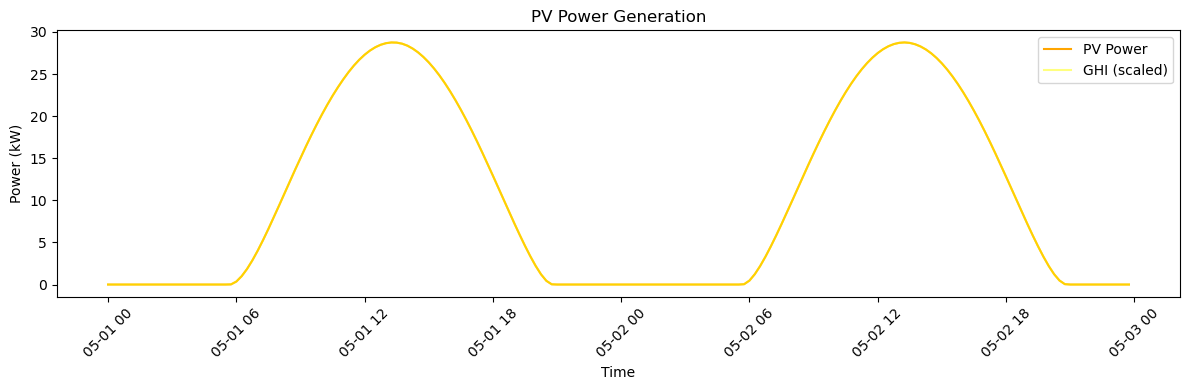

In [59]:
# Visualize PV power
plt.figure(figsize=(12, 4))
plt.plot(df.index, df['PV Power'], label='PV Power', color='orange')
plt.plot(df.index, df['GHI'] / df['GHI'].max() * df['PV Power'].max(), 
         label='GHI (scaled)', alpha=0.5, color='yellow')
plt.xlabel('Time')
plt.ylabel('Power (kW)')
plt.title('PV Power Generation')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Step 6: Configure Cooling System Properties


In [60]:
from utils.insulation_calculator import calculate_heat_transfer_coefficient

# Initialize dictionaries to store properties
mapping_of_walls_properties = {}
mapping_of_content_properties = {}

# For each cooling system (Pluskühlung, Tiefkühlung)
for system_config in COOLING_SYSTEMS:
    system_name = system_config['name']
    print(f"\n{system_name}:")
    
    # Calculate U-value
    if U_VALUE_OVERRIDE_W_PER_M2_K is not None:
        u_value = U_VALUE_OVERRIDE_W_PER_M2_K
        print(f"  Using U-value override: {u_value:.4f} W/(m²·K)")
    else:
        u_value = calculate_heat_transfer_coefficient(
            insulation_thickness=system_config['insulation_thickness'],
            insulation_type=system_config['insulation_type']
        )
        u_value = u_value * U_VALUE_CALIBRATION_FACTOR
        print(f"  Calculated U-value: {u_value:.4f} W/(m²·K)")
    
    # Calculate overall heat transfer coefficient (U × Area)
    # Calculate wall area from room dimensions
    # Assuming roughly square room: wall_area = 4 * sqrt(room_area) * room_height
    import math
    room_area = system_config['room_area_sqm']
    room_height = system_config['room_height_m']
    # For a square room, each side = sqrt(area), perimeter = 4*sqrt(area)
    # Wall area = perimeter * height = 4 * sqrt(area) * height
    wall_area = 4 * math.sqrt(room_area) * room_height
    print(f"  Room area: {room_area:.2f} m²")
    print(f"  Room height: {room_height:.2f} m")
    print(f"  Calculated wall area: {wall_area:.2f} m²")

    overall_u = u_value * wall_area
    print(f"  Overall U: {overall_u:.2f} W/K")
    
    # Store wall properties
    mapping_of_walls_properties[system_name] = {
        "area": wall_area,
        "heat_transfer_coef": u_value
    }
    
    # Calculate heat capacity
    # Calculate air mass from room volume
    # Air density at typical cold storage conditions: ~1.3 kg/m³
    air_density_kg_per_m3 = 1.3  # kg/m³ at ~0°C
    room_volume_m3 = room_area * room_height
    air_mass_kg = room_volume_m3 * air_density_kg_per_m3
    
    # Get content mass from config (room_content_mass_kg)
    content_mass_kg = system_config['room_content_mass_kg']
    
    # Specific heat capacity:
    # - Air: ~1005 J/(kg·K) at constant pressure
    # - Room contents (shelving, products): ~800-1200 J/(kg·K), use 1000 J/(kg·K) as average
    # For simplicity, use weighted average based on mass
    air_specific_heat_j_per_kg_k = 1005  # J/(kg·K)
    content_specific_heat_j_per_kg_k = 1000  # J/(kg·K) - average for typical storage room contents
    
    # Calculate total mass
    total_mass_kg = content_mass_kg + air_mass_kg
    # Calculate weighted average specific heat capacity
    if total_mass_kg > 0:
        avg_specific_heat = (
            (air_mass_kg * air_specific_heat_j_per_kg_k + 
             content_mass_kg * content_specific_heat_j_per_kg_k) / total_mass_kg
        )
    else:
        avg_specific_heat = 1000  # Default J/(kg·K)
    
    heat_capacity_j_per_k = total_mass_kg * avg_specific_heat
    print(f"  Heat capacity: {heat_capacity_j_per_k/1e6:.2f} MJ/K")
    
    # Store content properties
    # Store content properties
    mapping_of_content_properties[system_name] = {
        "mass": total_mass_kg,
        "specific_heat_capacity": avg_specific_heat
    }

print(f"\n\nWall properties: {mapping_of_walls_properties}")
print(f"Content properties: {mapping_of_content_properties}")



Pluskühlung 1:
  Using U-value override: 0.2000 W/(m²·K)
  Room area: 31.20 m²
  Room height: 2.85 m
  Calculated wall area: 63.68 m²
  Overall U: 12.74 W/K
  Heat capacity: 6.36 MJ/K

Pluskühlung 2:
  Using U-value override: 0.2000 W/(m²·K)
  Room area: 232.80 m²
  Room height: 2.85 m
  Calculated wall area: 173.94 m²
  Overall U: 34.79 W/K
  Heat capacity: 47.43 MJ/K

Tiefkühlung 1:
  Using U-value override: 0.2000 W/(m²·K)
  Room area: 135.36 m²
  Room height: 2.72 m
  Calculated wall area: 126.58 m²
  Overall U: 25.32 W/K
  Heat capacity: 27.55 MJ/K

Tiefkühlung 2:
  Using U-value override: 0.2000 W/(m²·K)
  Room area: 84.60 m²
  Room height: 5.49 m
  Calculated wall area: 201.98 m²
  Overall U: 40.40 W/K
  Heat capacity: 17.53 MJ/K


Wall properties: {'Pluskühlung 1': {'area': 63.676934599586374, 'heat_transfer_coef': 0.2}, 'Pluskühlung 2': {'area': 173.93874783957716, 'heat_transfer_coef': 0.2}, 'Tiefkühlung 1': {'area': 126.5826164368552, 'heat_transfer_coef': 0.2}, 'Tiefkühlun

## Step 7: Create Temperature Schedule


In [61]:
from analysis.schedule_creators import create_price_like_schedule
from analysis.cost_aware_schedule_creator import create_constrained_price_schedule

# For each system, create temperature schedule
for system_config in COOLING_SYSTEMS:
    system_name = system_config['name']
    print(f"\n{system_name}:")
    
    # Set temperature constraints
    df[f'{system_name}_Min Temp Allowed'] = system_config['min_temp_allowed_c']
    df[f'{system_name}_Max Temp Allowed'] = system_config['max_temp_allowed_c']
    df[f'{system_name}_Default Indoor Temp'] = system_config['default_temp_c']
    
    # Get schedule type for this system
    if 'Pluskühlung' in system_name:
        schedule_type = SCHEDULE_TEMP_TYPE_PLUSKUEHLUNG
        phase_change_temp = PHASE_CHANGE_TEMP_PLUSKUEHLUNG_C if PCM_MASS_PLUSKUEHLUNG_KG > 0 else None
    elif 'Tiefkühlung' in system_name:
        schedule_type = SCHEDULE_TEMP_TYPE_TIEFKUEHLUNG
        phase_change_temp = PHASE_CHANGE_TEMP_TIEFKUEHLUNG_C if PCM_MASS_TIEFKUEHLUNG_KG > 0 else None
    else:
        schedule_type = "price_like_schedule"
        phase_change_temp = None
    
    print(f"  Schedule type: {schedule_type}")
    print(f"  Phase change temp: {phase_change_temp}")
    
    # Create schedule
    if schedule_type == "price_like_schedule":
        df[f'{system_name}_Temperature Schedule'] = create_price_like_schedule(
            df=df,
            spotmarket_energy_price_col='Spot Market Price (€/MWh)',
            min_temp_allowed_col=f'{system_name}_Min Temp Allowed',
            max_temp_allowed_col=f'{system_name}_Max Temp Allowed',
            ramp_slope_in_k_per_h=abs(COOLING_RAMP_SLOPE_IN_K_PER_H),
            phase_change_temp=phase_change_temp,
        )
    elif schedule_type == "constrained_price_schedule":
        df[f'{system_name}_Temperature Schedule'] = create_constrained_price_schedule(
            df=df,
            spotmarket_energy_price_col='Spot Market Price (€/MWh)',
            min_temp_allowed_col=f'{system_name}_Min Temp Allowed',
            max_temp_allowed_col=f'{system_name}_Max Temp Allowed',
            dflt_indoor_temp_col=f'{system_name}_Default Indoor Temp',
            ramp_slope_in_k_per_h=abs(COOLING_RAMP_SLOPE_IN_K_PER_H),
            max_deviation_from_default=2.0,  # From config
            phase_change_temp=phase_change_temp,
        )
    
    col = f'{system_name}_Temperature Schedule'
    print(f"  Temperature range: {df[col].min():.2f} to {df[col].max():.2f} °C")
    print(f"  Mean: {df[col].mean():.2f} °C")



Pluskühlung 1:
  Schedule type: price_like_schedule
  Phase change temp: 0.0
  Temperature range: 0.00 to 4.00 °C
  Mean: 2.71 °C

Pluskühlung 2:
  Schedule type: price_like_schedule
  Phase change temp: 0.0
  Temperature range: 0.00 to 4.00 °C
  Mean: 2.71 °C

Tiefkühlung 1:
  Schedule type: constrained_price_schedule
  Phase change temp: -20.0
  Temperature range: -22.00 to -18.00 °C
  Mean: -19.29 °C

Tiefkühlung 2:
  Schedule type: constrained_price_schedule
  Phase change temp: -20.0
  Temperature range: -22.00 to -18.00 °C
  Mean: -19.29 °C


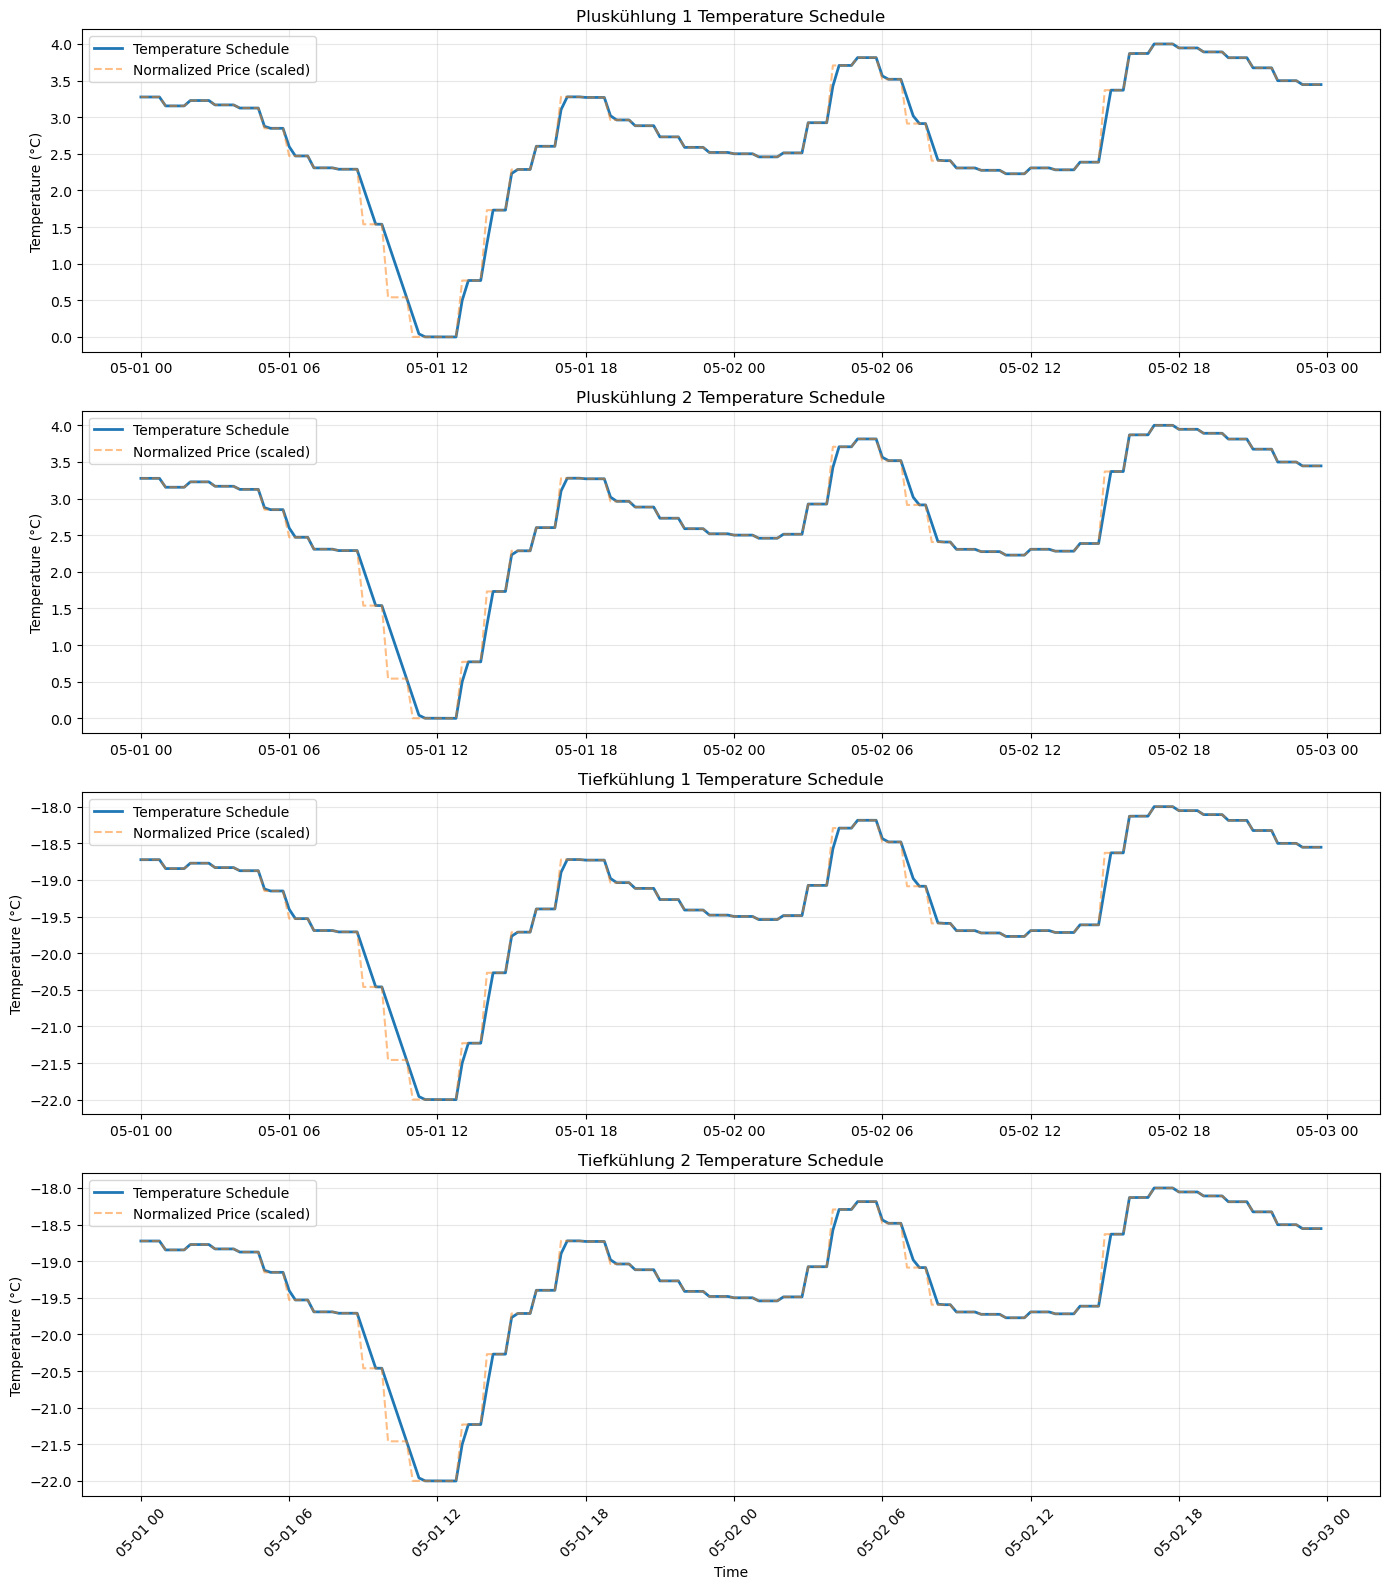

In [62]:
# Visualize temperature schedules
fig, axes = plt.subplots(len(COOLING_SYSTEMS), 1, figsize=(14, 4*len(COOLING_SYSTEMS)))
if len(COOLING_SYSTEMS) == 1:
    axes = [axes]

for idx, system_config in enumerate(COOLING_SYSTEMS):
    system_name = system_config['name']
    col = f'{system_name}_Temperature Schedule'
    
    # Normalize price for comparison
    price_normalized = (df['Spot Market Price (€/MWh)'] - df['Spot Market Price (€/MWh)'].min()) / \
                      (df['Spot Market Price (€/MWh)'].max() - df['Spot Market Price (€/MWh)'].min())
    price_scaled = price_normalized * (df[col].max() - df[col].min()) + df[col].min()
    
    axes[idx].plot(df.index, df[col], label='Temperature Schedule', linewidth=2)
    axes[idx].plot(df.index, price_scaled, label='Normalized Price (scaled)', alpha=0.5, linestyle='--')
    axes[idx].set_ylabel('Temperature (°C)')
    axes[idx].set_title(f'{system_name} Temperature Schedule')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

axes[-1].set_xlabel('Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Step 8: PV Self-Consumption Optimization (Optional)


In [63]:
# Skip this step if PV optimization is not needed
# Set this to False to skip PV optimization
ENABLE_PV_OPTIMIZATION = True

if ENABLE_PV_OPTIMIZATION and 'PV Power' in df.columns:
    from analysis.pv_self_consumption_optimizer import optimize_pv_self_consumption
    from utils.data_processing import determine_surplus_phases
    from analysis.phase_change_analysis_tool import _convert_surplus_phases_to_daily_format
    
    # Determine surplus phases (when PV > consumption)
    surplus_phases = determine_surplus_phases(
        df=df,
        pv_power_col='PV Power',
        site_consumption_col='Standortverbrauch'
    )
    
    print(f"Number of surplus phases: {len(surplus_phases)}")
    if len(surplus_phases) > 0:
        total_surplus_hours = sum((end - start).total_seconds() / 3600 for start, end in surplus_phases)
        print(f"Total surplus time: {total_surplus_hours:.1f} hours")
    
    # Convert surplus phases to daily format
    surplus_phases_by_day = _convert_surplus_phases_to_daily_format(df, surplus_phases)
    
    # Optimize each system's schedule
for system_config in COOLING_SYSTEMS:
    system_name = system_config['name']
    schedule_col = f'{system_name}_Temperature Schedule'

    # Get phase change temp
    if 'Pluskühlung' in system_name:
        phase_change_temp = PHASE_CHANGE_TEMP_PLUSKUEHLUNG_C if PCM_MASS_PLUSKUEHLUNG_KG > 0 else None
    elif 'Tiefkühlung' in system_name:
        phase_change_temp = PHASE_CHANGE_TEMP_TIEFKUEHLUNG_C if PCM_MASS_TIEFKUEHLUNG_KG > 0 else None
    else:
        phase_change_temp = None

    df[schedule_col] = optimize_pv_self_consumption(
            schedule_temp=df[schedule_col],
            expected_surplus_phases=surplus_phases_by_day,
            shortest_surplus_phase_allowed="1h",
            cooling_ramp_slope_in_k_per_h=COOLING_RAMP_SLOPE_IN_K_PER_H,
            warming_ramp_slope_in_k_per_h=WARMING_RAMP_SLOPE_IN_K_PER_H,
            min_temp_allowed=system_config['min_temp_allowed_c'],
            max_temp_allowed=system_config['max_temp_allowed_c'],
        phase_change_temp=phase_change_temp,
        )
    print(f"{system_name}: PV optimization applied")
else:
    print("PV optimization skipped")


Number of surplus phases: 2
Total surplus time: 22.8 hours
Pluskühlung 1: PV optimization applied
Pluskühlung 2: PV optimization applied
Tiefkühlung 1: PV optimization applied
Tiefkühlung 2: PV optimization applied
PV optimization skipped


## Step 9: Calculate Cooling Power (Temperature → Electrical Load)


In [64]:
from analysis.phase_change_models import calculate_phase_change_cooling_power

# For each system, calculate cooling power
for system_config in COOLING_SYSTEMS:
    system_name = system_config['name']
    print(f"\n{system_name}:")
    
    # Get system-specific parameters
    if 'Pluskühlung' in system_name:
        latent_heat = LATENT_HEAT_CAPACITY_PLUSKUEHLUNG_J_PER_KG
        pcm_mass = PCM_MASS_PLUSKUEHLUNG_KG
        phase_change_temp = PHASE_CHANGE_TEMP_PLUSKUEHLUNG_C
        latent_heat_factor = LATENT_HEAT_FACTOR_PLUSKUEHLUNG
    elif 'Tiefkühlung' in system_name:
        latent_heat = LATENT_HEAT_CAPACITY_TIEFKUEHLUNG_J_PER_KG
        pcm_mass = PCM_MASS_TIEFKUEHLUNG_KG
        phase_change_temp = PHASE_CHANGE_TEMP_TIEFKUEHLUNG_C
        latent_heat_factor = LATENT_HEAT_FACTOR_TIEFKUEHLUNG
    else:
        latent_heat = 200000
        pcm_mass = 0
        phase_change_temp = 0
        latent_heat_factor = 1.0
    
    # Get wall and content properties
    wall_props = mapping_of_walls_properties[system_name]
    content_props = mapping_of_content_properties[system_name]
    
    # Calculate overall heat transfer coefficient
    overall_u = wall_props['area'] * wall_props['heat_transfer_coef']
    
    # Calculate overall heat capacity
    overall_heat_capacity = content_props['mass'] * content_props['specific_heat_capacity']
    
    print(f"  Overall U: {overall_u:.2f} W/K")
    print(f"  Heat capacity: {overall_heat_capacity/1e6:.2f} MJ/K")
    print(f"  PCM mass: {pcm_mass} kg")
    
    # Calculate cooling power
    df[f'{system_name}_Cooling Power After Optimization'] = calculate_phase_change_cooling_power(
        df=df,
        cooling_power_col='Standortverbrauch',  # Baseline cooling
        schedule_temp_col=f'{system_name}_Temperature Schedule',
        dflt_indoor_temp_col=f'{system_name}_Default Indoor Temp',
        overall_heat_transfer_coef_in_w_per_k=overall_u,
        overall_heat_capacity_in_j_per_k=overall_heat_capacity,
        latent_heat_capacity_in_j_per_kg=latent_heat,
        pcm_mass_in_kg=pcm_mass,
        phase_change_temp_in_c=phase_change_temp,
        cop=COP,
        latent_heat_factor=latent_heat_factor,
    )
    
    col = f'{system_name}_Cooling Power After Optimization'
    print(f"  Cooling power range: {df[col].min():.2f} to {df[col].max():.2f} kW")
    print(f"  Mean: {df[col].mean():.2f} kW")
    print(f"  Total energy: {df[col].sum() * 0.25:.2f} kWh")



Pluskühlung 1:
  Overall U: 12.74 W/K
  Heat capacity: 6.36 MJ/K
  PCM mass: 1000 kg
  Cooling power range: 0.03 to 5.44 kW
  Mean: 1.63 kW
  Total energy: 78.05 kWh

Pluskühlung 2:
  Overall U: 34.79 W/K
  Heat capacity: 47.43 MJ/K
  PCM mass: 1000 kg
  Cooling power range: 0.07 to 8.64 kW
  Mean: 1.84 kW
  Total energy: 88.44 kWh

Tiefkühlung 1:
  Overall U: 25.32 W/K
  Heat capacity: 27.55 MJ/K
  PCM mass: 1000 kg
  Cooling power range: 0.23 to 7.82 kW
  Mean: 1.36 kW
  Total energy: 65.49 kWh

Tiefkühlung 2:
  Overall U: 40.40 W/K
  Heat capacity: 17.53 MJ/K
  PCM mass: 1000 kg
  Cooling power range: 0.37 to 6.91 kW
  Mean: 1.49 kW
  Total energy: 71.41 kWh


## Step 10: Calculate EVU and Grid Power After Optimization


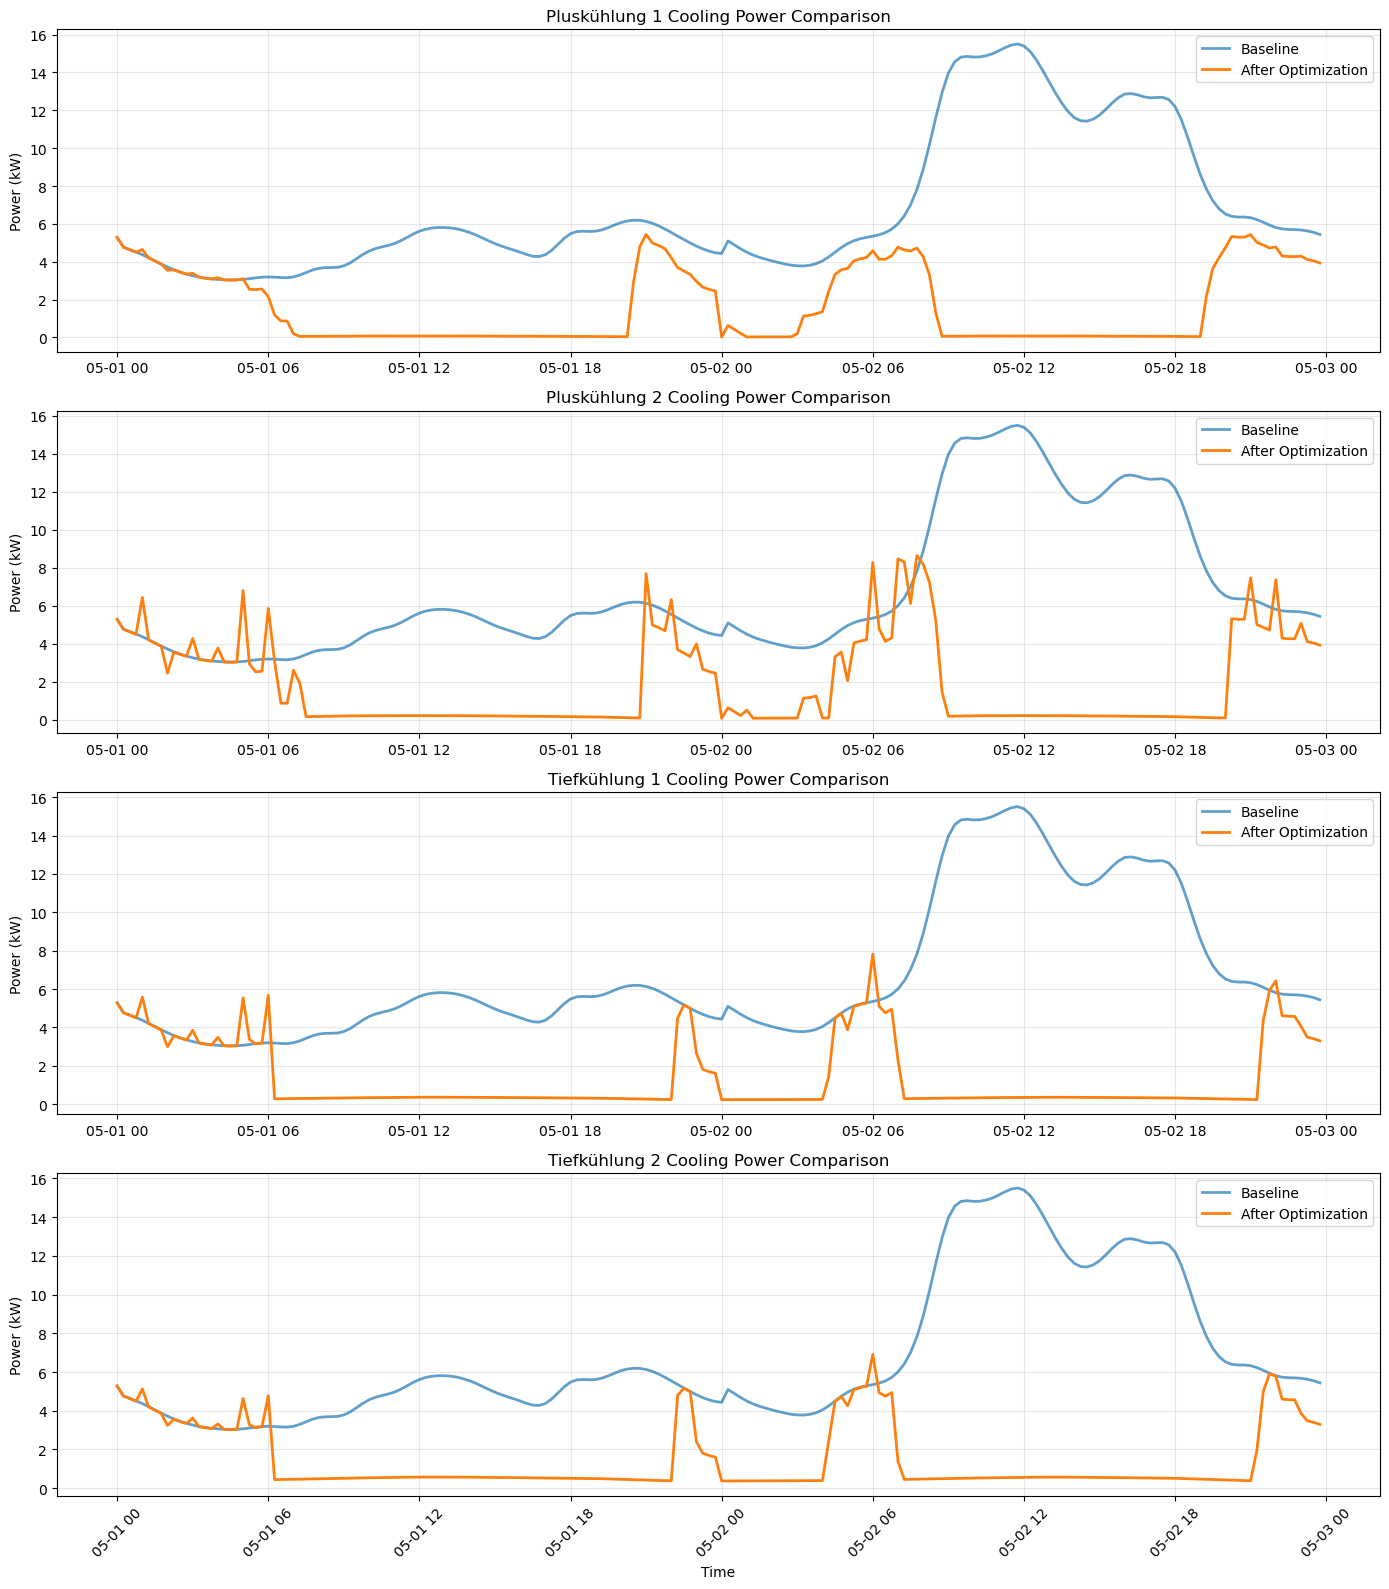

In [65]:
# Compare cooling power with baseline
fig, axes = plt.subplots(len(COOLING_SYSTEMS), 1, figsize=(14, 4*len(COOLING_SYSTEMS)))
if len(COOLING_SYSTEMS) == 1:
    axes = [axes]

for idx, system_config in enumerate(COOLING_SYSTEMS):
    system_name = system_config['name']
    col = f'{system_name}_Cooling Power After Optimization'
    
    axes[idx].plot(df.index, df['Standortverbrauch'], label='Baseline', linewidth=2, alpha=0.7)
    axes[idx].plot(df.index, df[col], label='After Optimization', linewidth=2)
    axes[idx].set_ylabel('Power (kW)')
    axes[idx].set_title(f'{system_name} Cooling Power Comparison')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

axes[-1].set_xlabel('Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [49]:
# For each system
for system_config in COOLING_SYSTEMS:
    system_name = system_config['name']
    cooling_after_col = f'{system_name}_Cooling Power After Optimization'
    
    # Calculate EVU after optimization
    # EVU_after = EVU_before - cooling_before + cooling_after
    df[f'{system_name}_EVU After Optimization'] = (
        df['Standortverbrauch']  # EVU before (gross consumption)
        - df['Standortverbrauch']  # Subtract baseline cooling (assuming it's part of Standortverbrauch)
        + df[cooling_after_col]  # Add optimized cooling
    )
    
    # Calculate site consumption (same as EVU for gross consumption)
    df[f'{system_name}_Site Consumption After'] = df[f'{system_name}_EVU After Optimization']
    
    # Calculate EVU Meter (net grid exchange)
    if 'PV Power' in df.columns:
        df[f'{system_name}_EVU Meter After'] = (
            df[f'{system_name}_EVU After Optimization'] - df['PV Power']
        )
    else:
        df[f'{system_name}_EVU Meter After'] = df[f'{system_name}_EVU After Optimization']
    
    # Calculate grid power (only when drawing from grid)
    df[f'{system_name}_Grid Power After'] = df[f'{system_name}_EVU Meter After'].clip(lower=0)
    
    print(f"\n{system_name}:")
    print(f"  EVU After (mean): {df[f'{system_name}_EVU After Optimization'].mean():.2f} kW")
    print(f"  Grid Power After (mean): {df[f'{system_name}_Grid Power After'].mean():.2f} kW")
    if 'PV Power' in df.columns:
        self_consumption = (df['PV Power'] - df[f'{system_name}_EVU Meter After'].clip(lower=0)).sum() * 0.25
        print(f"  PV Self-consumption: {self_consumption:.2f} kWh")



Pluskühlung 1:
  EVU After (mean): 1.20 kW
  Grid Power After (mean): 0.95 kW
  PV Self-consumption: 452.13 kWh

Pluskühlung 2:
  EVU After (mean): 1.63 kW
  Grid Power After (mean): 1.26 kW
  PV Self-consumption: 437.12 kWh

Tiefkühlung 1:
  EVU After (mean): 0.67 kW
  Grid Power After (mean): 0.47 kW
  PV Self-consumption: 475.16 kWh

Tiefkühlung 2:
  EVU After (mean): 0.80 kW
  Grid Power After (mean): 0.48 kW
  PV Self-consumption: 474.53 kWh


## Step 11: Calculate Costs and Savings


In [50]:
from utils.data_processing import convert_power_to_energy

# For each system
for system_config in COOLING_SYSTEMS:
    system_name = system_config['name']
    # Calculate grid power before (baseline)
    if 'PV Power' in df.columns:
        df[f'{system_name}_EVU Meter Before'] = df['Standortverbrauch'] - df['PV Power']
        df[f'{system_name}_Grid Power Before'] = df[f'{system_name}_EVU Meter Before'].clip(lower=0)
    else:
        df[f'{system_name}_Grid Power Before'] = df['Standortverbrauch']
    
    grid_before_col = f'{system_name}_Grid Power Before'
    grid_after_col = f'{system_name}_Grid Power After'
    
    # Convert prices to ct/kWh
    df[f'{system_name}_Spot Market Price (ct/kWh)'] = df['Spot Market Price (€/MWh)'] * 0.1
    
    # Calculate hourly energy costs
    time_step_hours = 0.25  # 15 minutes
    df[f'{system_name}_Cost Before (€/h)'] = (
        df[grid_before_col] * time_step_hours 
        * df[f'{system_name}_Spot Market Price (ct/kWh)'] / 100
    )
    df[f'{system_name}_Cost After (€/h)'] = (
        df[grid_after_col] * time_step_hours 
        * df[f'{system_name}_Spot Market Price (ct/kWh)'] / 100
    )
    
    # Calculate cumulative energy consumption
    df[f'{system_name}_Energy Consumption Before (kWh)'] = convert_power_to_energy(df[grid_before_col])
    df[f'{system_name}_Energy Consumption After (kWh)'] = convert_power_to_energy(df[grid_after_col])
    
    # Calculate total costs
    grid_costs_before = df[f'{system_name}_Cost Before (€/h)'].sum()
    grid_costs_after = df[f'{system_name}_Cost After (€/h)'].sum()
    
    # Calculate power costs (based on max power)
    max_power_before = df[grid_before_col].max()
    max_power_after = df[grid_after_col].max()
    power_cost_before = max_power_before * POWER_PRICE_IN_EURO_PER_KW
    power_cost_after = max_power_after * POWER_PRICE_IN_EURO_PER_KW
    
    # Total costs
    total_cost_before = grid_costs_before + power_cost_before
    total_cost_after = grid_costs_after + power_cost_after
    
    # Calculate savings
    absolute_savings = total_cost_before - total_cost_after
    relative_savings = (absolute_savings / total_cost_before * 100) if total_cost_before > 0 else 0
    
    print(f"\n{system_name} Cost Analysis:")
    print(f"  Energy cost before: {grid_costs_before:.2f} €")
    print(f"  Energy cost after: {grid_costs_after:.2f} €")
    print(f"  Power cost before: {power_cost_before:.2f} €")
    print(f"  Power cost after: {power_cost_after:.2f} €")
    print(f"  Total cost before: {total_cost_before:.2f} €")
    print(f"  Total cost after: {total_cost_after:.2f} €")
    print(f"  Absolute savings: {absolute_savings:.2f} €")
    print(f"  Relative savings: {relative_savings:.1f} %")



Pluskühlung 1 Cost Analysis:
  Energy cost before: 2.95 €
  Energy cost after: 1.37 €
  Power cost before: 632.75 €
  Power cost after: 483.22 €
  Total cost before: 635.71 €
  Total cost after: 484.59 €
  Absolute savings: 151.11 €
  Relative savings: 23.8 %

Pluskühlung 2 Cost Analysis:
  Energy cost before: 2.95 €
  Energy cost after: 1.42 €
  Power cost before: 632.75 €
  Power cost after: 805.96 €
  Total cost before: 635.71 €
  Total cost after: 807.38 €
  Absolute savings: -171.67 €
  Relative savings: -27.0 %

Tiefkühlung 1 Cost Analysis:
  Energy cost before: 2.95 €
  Energy cost after: 0.64 €
  Power cost before: 632.75 €
  Power cost after: 724.66 €
  Total cost before: 635.71 €
  Total cost after: 725.30 €
  Absolute savings: -89.59 €
  Relative savings: -14.1 %

Tiefkühlung 2 Cost Analysis:
  Energy cost before: 2.95 €
  Energy cost after: 0.68 €
  Power cost before: 632.75 €
  Power cost after: 633.73 €
  Total cost before: 635.71 €
  Total cost after: 634.42 €
  Absolut

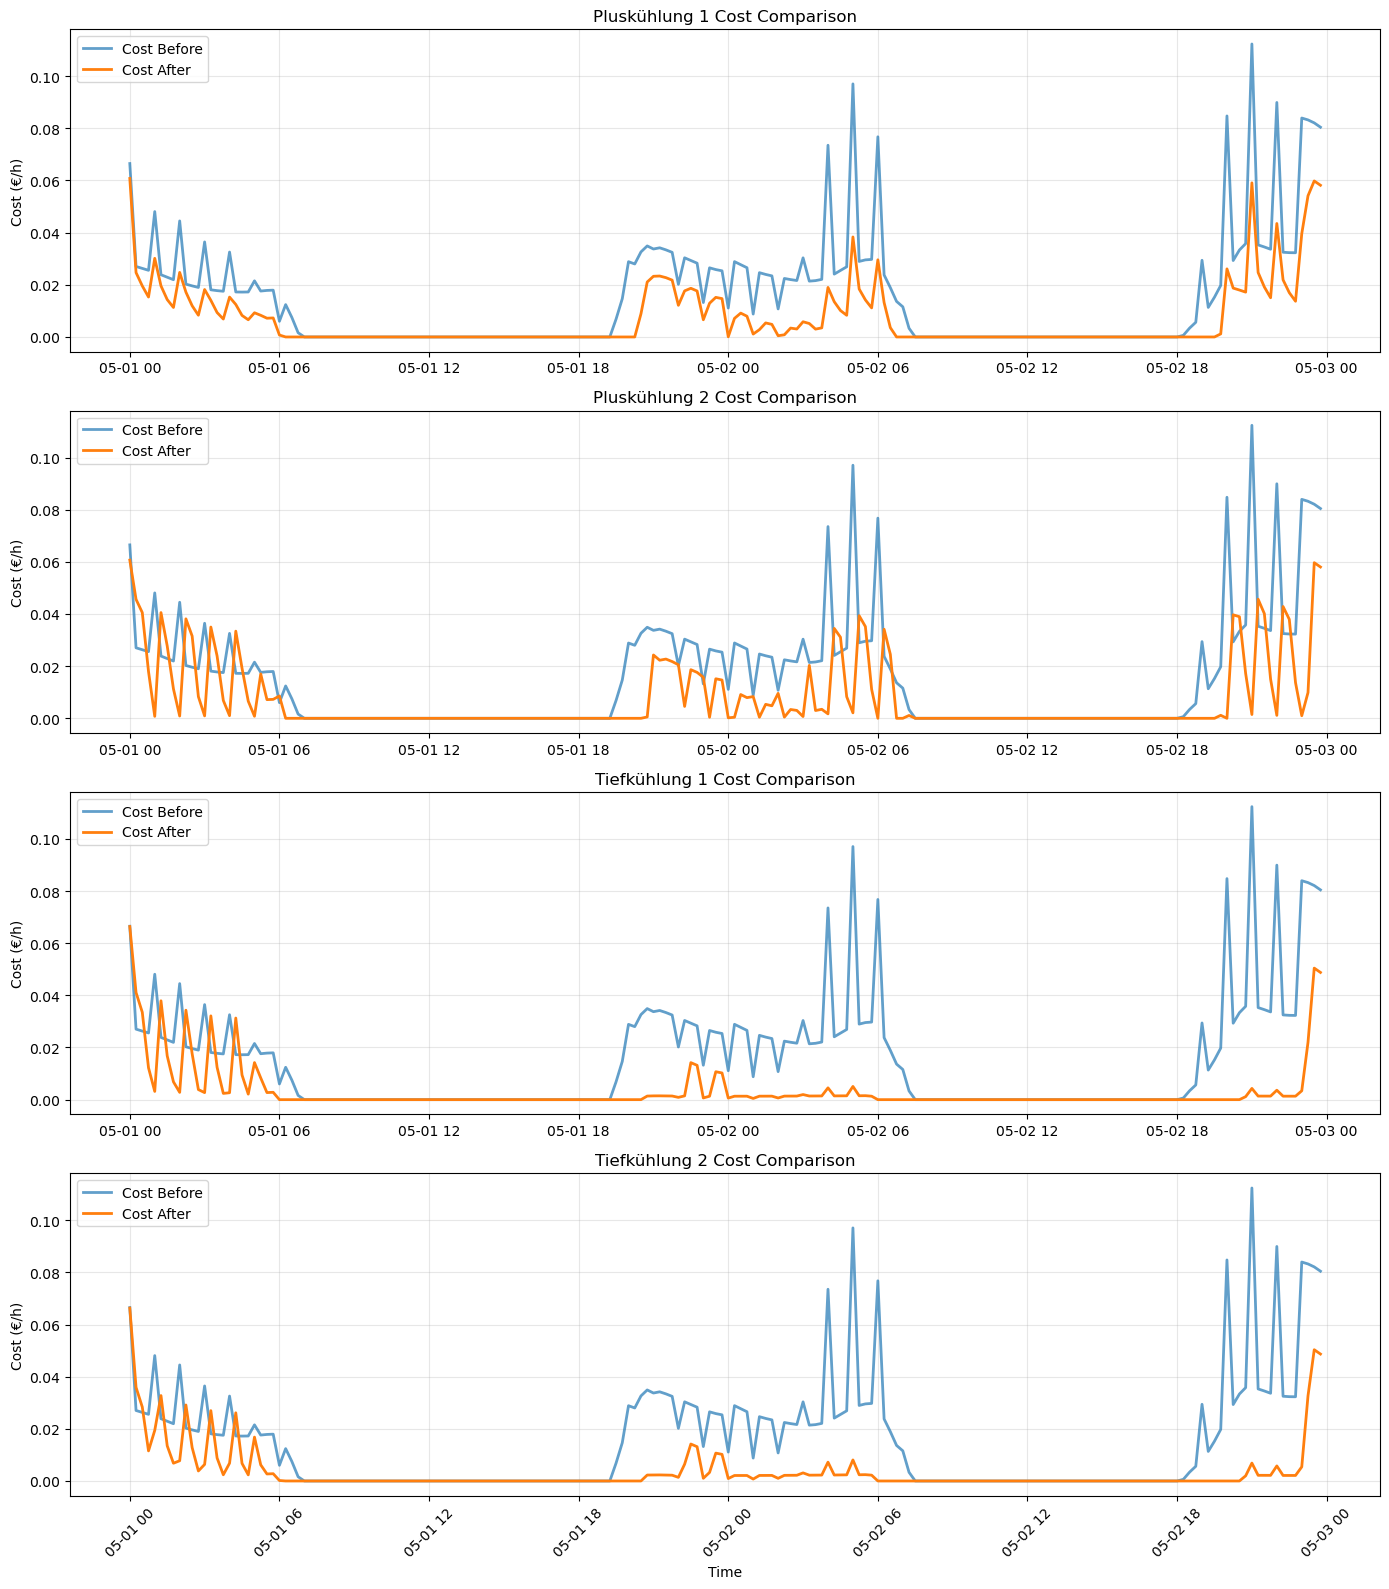

In [51]:
# Visualize cost comparison
fig, axes = plt.subplots(len(COOLING_SYSTEMS), 1, figsize=(14, 4*len(COOLING_SYSTEMS)))
if len(COOLING_SYSTEMS) == 1:
    axes = [axes]

for idx, system_config in enumerate(COOLING_SYSTEMS):
    system_name = system_config['name']
    axes[idx].plot(df.index, df[f'{system_name}_Cost Before (€/h)'], 
                   label='Cost Before', linewidth=2, alpha=0.7)
    axes[idx].plot(df.index, df[f'{system_name}_Cost After (€/h)'], 
                   label='Cost After', linewidth=2)
    axes[idx].set_ylabel('Cost (€/h)')
    axes[idx].set_title(f'{system_name} Cost Comparison')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

axes[-1].set_xlabel('Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Step 12: Validate Temperature Schedule


In [52]:
from analysis.temperature_validation import validate_temperature_schedule

# For each system
for system_config in COOLING_SYSTEMS:
    system_name = system_config['name']
    print(f"\n{system_name}:")
    
    # Get validation tolerance
    if 'Pluskühlung' in system_name:
        tolerance = VALIDATION_TOLERANCE_PLUSKUEHLUNG_C
    elif 'Tiefkühlung' in system_name:
        tolerance = VALIDATION_TOLERANCE_TIEFKUEHLUNG_C
    else:
        tolerance = 1.0
    
    # Get system properties
    wall_props = mapping_of_walls_properties[system_name]
    content_props = mapping_of_content_properties[system_name]
    overall_u = wall_props['area'] * wall_props['heat_transfer_coef']
    overall_heat_capacity = content_props['mass'] * content_props['specific_heat_capacity']
    
    # Get PCM parameters
    if 'Pluskühlung' in system_name:
        latent_heat_factor = LATENT_HEAT_FACTOR_PLUSKUEHLUNG
    elif 'Tiefkühlung' in system_name:
        latent_heat_factor = LATENT_HEAT_FACTOR_TIEFKUEHLUNG
    else:
        latent_heat_factor = 1.0
    
    # Validate temperature schedule
    validation_results = validate_temperature_schedule(
        df=df,
        target_temp_col=f'{system_name}_Temperature Schedule',
        cooling_power_col=f'{system_name}_Cooling Power After Optimization',
        initial_temp=system_config['default_temp_c'],
        overall_heat_transfer_coef_in_w_per_k=overall_u,
        overall_heat_capacity_in_j_per_k=overall_heat_capacity,
        cop=COP,
        latent_heat_factor=latent_heat_factor,
        baseline_cooling_power_col='Standortverbrauch',
        dflt_indoor_temp=system_config['default_temp_c'],
        tolerance=tolerance,
    )
    
    # Add simulated temperature to DataFrame
    df[f'{system_name}_Simulated Temperature'] = validation_results['simulated_temperature']
    df[f'{system_name}_Temperature Error'] = validation_results['errors']
    
    # Print validation summary
    print(f"  Mean Absolute Error: {validation_results['mean_abs_error']:.3f} °C")
    print(f"  Max Error: {validation_results['max_error']:.3f} °C")
    print(f"  RMSE: {validation_results['rmse']:.3f} °C")
    print(f"  Within Tolerance ({tolerance}°C): {validation_results['within_tolerance']:.1f}%")
    print(f"  Validation Status: {'PASSED' if validation_results['validation_passed'] else 'FAILED'}")



Pluskühlung 1:
[INFO] Using estimated outside temperature based on month (5): 14.0C average, with daily variation
  Mean Absolute Error: 37.669 °C
  Max Error: 82.511 °C
  RMSE: 42.560 °C
  Within Tolerance (2.0°C): 0.5%
  Validation Status: FAILED

Pluskühlung 2:
[INFO] Using estimated outside temperature based on month (5): 14.0C average, with daily variation
  Mean Absolute Error: 7.380 °C
  Max Error: 16.919 °C
  RMSE: 8.393 °C
  Within Tolerance (2.0°C): 2.1%
  Validation Status: FAILED

Tiefkühlung 1:
[INFO] Using estimated outside temperature based on month (5): 14.0C average, with daily variation
  Mean Absolute Error: 3.495 °C
  Max Error: 7.662 °C
  RMSE: 4.310 °C
  Within Tolerance (1.0°C): 28.6%
  Validation Status: FAILED

Tiefkühlung 2:
[INFO] Using estimated outside temperature based on month (5): 14.0C average, with daily variation
  Mean Absolute Error: 4.627 °C
  Max Error: 8.910 °C
  RMSE: 5.307 °C
  Within Tolerance (1.0°C): 0.0%
  Validation Status: FAILED


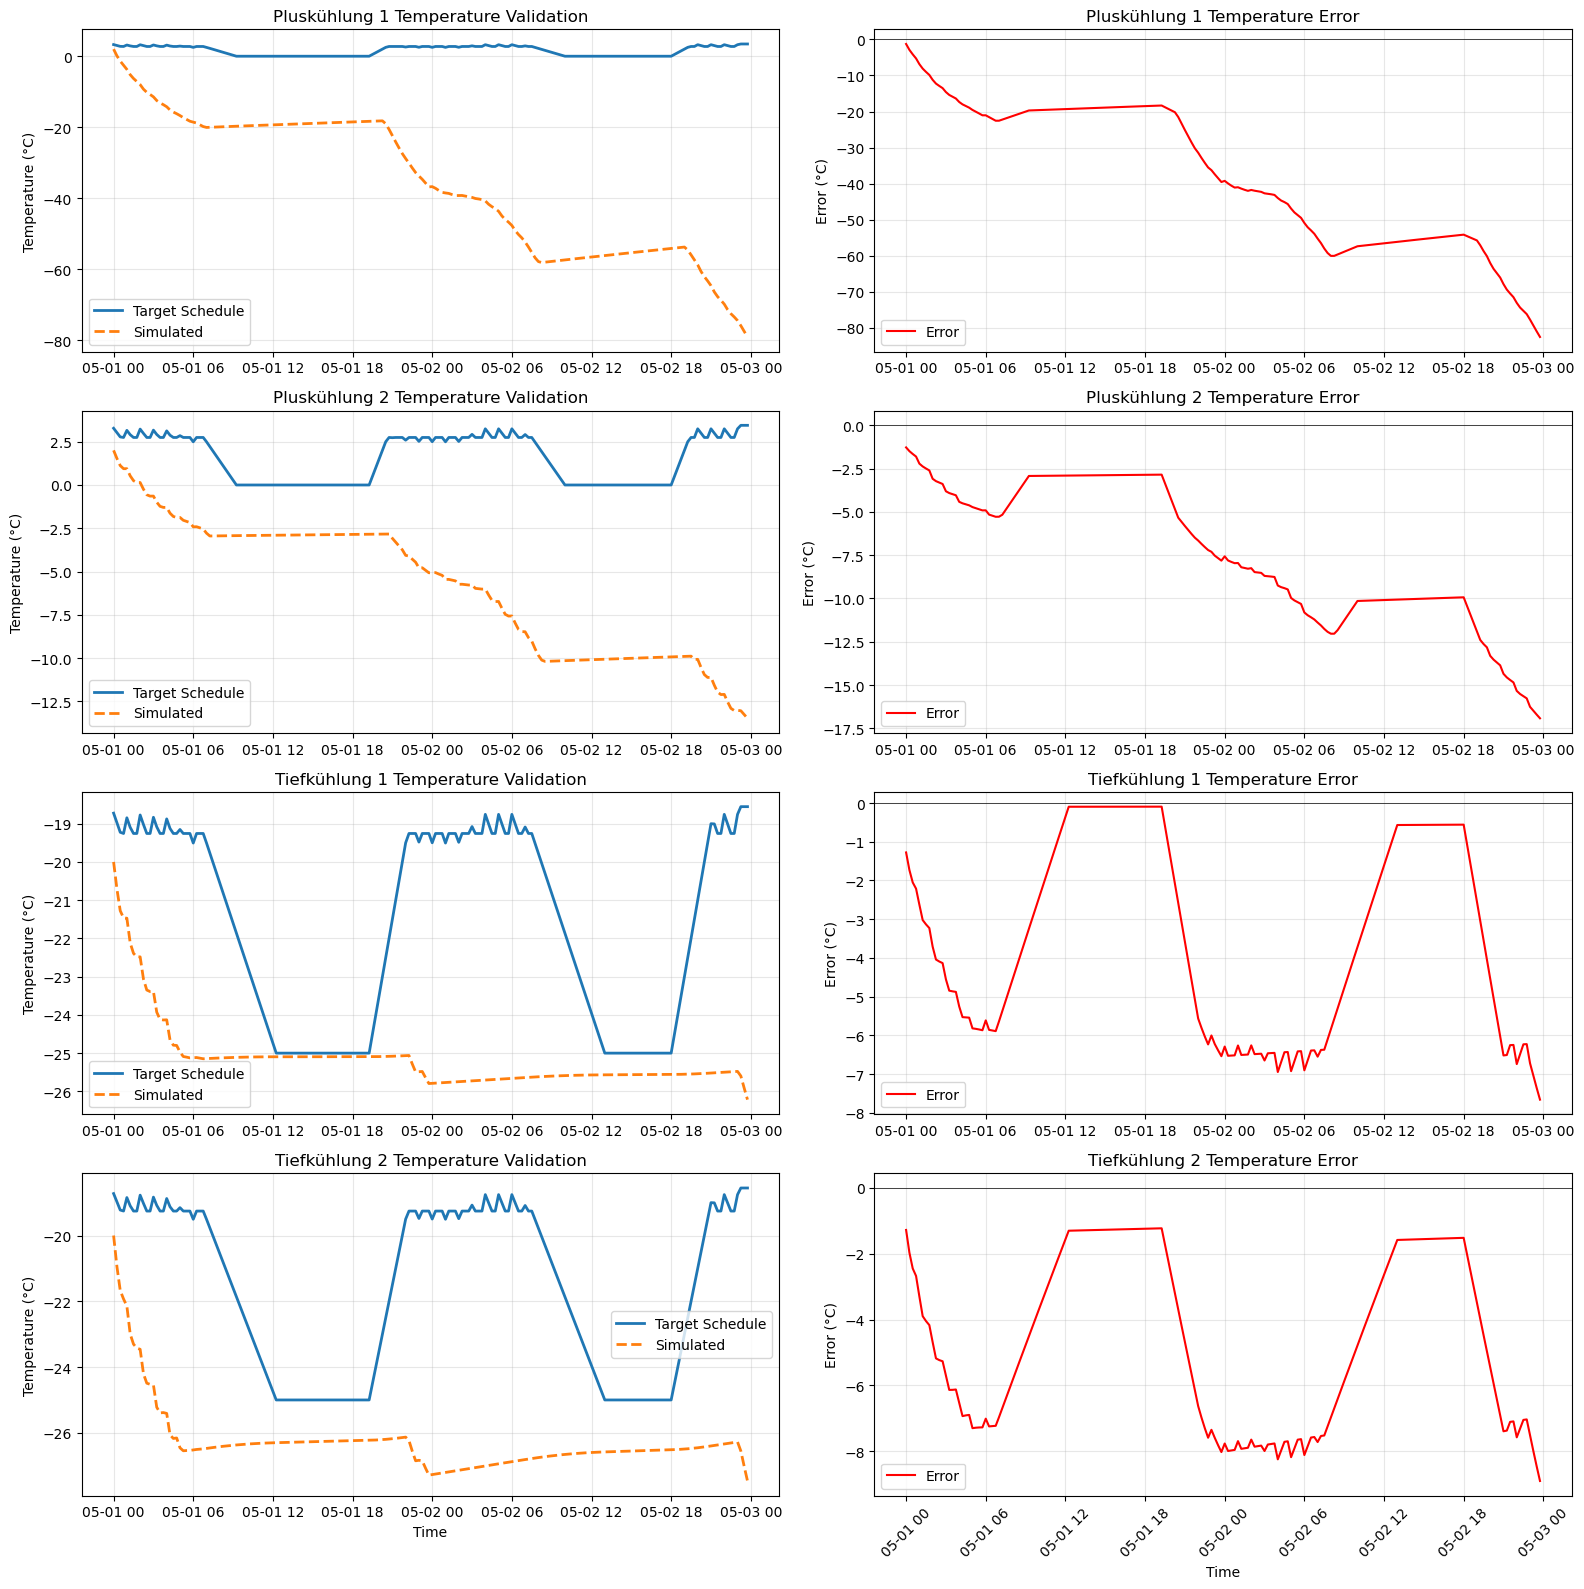

In [53]:
# Plot validation results
fig, axes = plt.subplots(len(COOLING_SYSTEMS), 2, figsize=(16, 4*len(COOLING_SYSTEMS)))
if len(COOLING_SYSTEMS) == 1:
    axes = axes.reshape(1, -1)

for idx, system_config in enumerate(COOLING_SYSTEMS):
    system_name = system_config['name']
    # Plot 1: Temperature comparison
    axes[idx, 0].plot(df.index, df[f'{system_name}_Temperature Schedule'], 
                      label='Target Schedule', linewidth=2)
    axes[idx, 0].plot(df.index, df[f'{system_name}_Simulated Temperature'], 
                      label='Simulated', linewidth=2, linestyle='--')
    axes[idx, 0].set_ylabel('Temperature (°C)')
    axes[idx, 0].set_title(f'{system_name} Temperature Validation')
    axes[idx, 0].legend()
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Plot 2: Error
    axes[idx, 1].plot(df.index, df[f'{system_name}_Temperature Error'], 
                      label='Error', color='red')
    axes[idx, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[idx, 1].set_ylabel('Error (°C)')
    axes[idx, 1].set_title(f'{system_name} Temperature Error')
    axes[idx, 1].legend()
    axes[idx, 1].grid(True, alpha=0.3)

axes[-1, 0].set_xlabel('Time')
axes[-1, 1].set_xlabel('Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Step 13: Generate Reports


In [54]:
from utils.plotting import PhaseChangePlotter

# For each system, generate reports
for system_config in COOLING_SYSTEMS:
    system_name = system_config['name']
    system_report_dir = os.path.join(report_directory, system_name)
    os.makedirs(system_report_dir, exist_ok=True)
    
    # Prepare DataFrame for this system
    system_df = df[[
        'Standortverbrauch',
        'PV Power',
        'Spot Market Price (€/MWh)',
        f'{system_name}_Temperature Schedule',
        f'{system_name}_Cooling Power After Optimization',
        f'{system_name}_Grid Power Before',
        f'{system_name}_Grid Power After',
        f'{system_name}_Cost Before (€/h)',
        f'{system_name}_Cost After (€/h)',
        f'{system_name}_Energy Consumption Before (kWh)',
        f'{system_name}_Energy Consumption After (kWh)',
        f'{system_name}_Simulated Temperature',
        f'{system_name}_Temperature Error',
    ]].copy()
    
    # Rename columns for plotting (remove system name prefix)
    rename_dict = {
        f'{system_name}_Temperature Schedule': 'Temperature Schedule',
        f'{system_name}_Cooling Power After Optimization': 'Cooling Power After Optimization',
        f'{system_name}_Grid Power Before': 'Grid Power Before',
        f'{system_name}_Grid Power After': 'Grid Power After',
        f'{system_name}_Cost Before (€/h)': 'Cost Before (€/h)',
        f'{system_name}_Cost After (€/h)': 'Cost After (€/h)',
        f'{system_name}_Energy Consumption Before (kWh)': 'Energy Consumption Before (kWh)',
        f'{system_name}_Energy Consumption After (kWh)': 'Energy Consumption After (kWh)',
        f'{system_name}_Simulated Temperature': 'Simulated Temperature',
        f'{system_name}_Temperature Error': 'Temperature Error',
    }
    system_df = system_df.rename(columns=rename_dict)
    
    # Save Excel report
    excel_path = os.path.join(system_report_dir, 'results.xlsx')
    system_df.to_excel(excel_path, index=True)
    print(f"\n{system_name} Excel report saved: {excel_path}")



Pluskühlung 1 Excel report saved: reports/bako/manual_analysis\Pluskühlung 1\results.xlsx

Pluskühlung 2 Excel report saved: reports/bako/manual_analysis\Pluskühlung 2\results.xlsx

Tiefkühlung 1 Excel report saved: reports/bako/manual_analysis\Tiefkühlung 1\results.xlsx

Tiefkühlung 2 Excel report saved: reports/bako/manual_analysis\Tiefkühlung 2\results.xlsx


In [55]:
# Generate HTML plots
for system_config in COOLING_SYSTEMS:
    system_name = system_config['name']
    system_report_dir = os.path.join(report_directory, system_name)
    
    # Prepare DataFrame (reuse from previous cell)
    system_df = df[[
        'Standortverbrauch',
        'PV Power',
        'Spot Market Price (€/MWh)',
        f'{system_name}_Temperature Schedule',
        f'{system_name}_Cooling Power After Optimization',
        f'{system_name}_Grid Power Before',
        f'{system_name}_Grid Power After',
        f'{system_name}_Cost Before (€/h)',
        f'{system_name}_Cost After (€/h)',
        f'{system_name}_Energy Consumption Before (kWh)',
        f'{system_name}_Energy Consumption After (kWh)',
    ]].copy()
    
    # Rename columns
    rename_dict = {
        f'{system_name}_Temperature Schedule': 'Temperature Schedule',
        f'{system_name}_Cooling Power After Optimization': 'Cooling Power After Optimization',
        f'{system_name}_Grid Power Before': 'Grid Power Before',
        f'{system_name}_Grid Power After': 'Grid Power After',
        f'{system_name}_Cost Before (€/h)': 'Cost Before (€/h)',
        f'{system_name}_Cost After (€/h)': 'Cost After (€/h)',
        f'{system_name}_Energy Consumption Before (kWh)': 'Energy Consumption Before (kWh)',
        f'{system_name}_Energy Consumption After (kWh)': 'Energy Consumption After (kWh)',
    }
    system_df = system_df.rename(columns=rename_dict)
    
    # Generate plots
    plotter = PhaseChangePlotter(system_df)
    
    # Grid power comparison
    plotter.plot_comparison(
        before_col='Grid Power Before',
        after_col='Grid Power After',
        title=f'{system_name} Grid Power Comparison',
        save_path=os.path.join(system_report_dir, 'grid_power_comparison.html'),
    )
    
    # Cost comparison
    plotter.plot_comparison(
        before_col='Cost Before (€/h)',
        after_col='Cost After (€/h)',
        title=f'{system_name} Cost Comparison',
        save_path=os.path.join(system_report_dir, 'cost_comparison.html'),
    )
    
    # Energy consumption comparison
    plotter.plot_comparison(
        before_col='Energy Consumption Before (kWh)',
        after_col='Energy Consumption After (kWh)',
        title=f'{system_name} Energy Consumption Comparison',
        save_path=os.path.join(system_report_dir, 'energy_consumption_comparison.html'),
    )
    
    # Comprehensive analysis
    plotter.plot_power_curves(
        power_cols=['PV Power'] if 'PV Power' in system_df.columns else [],
        energy_price_col='Spot Market Price (€/MWh)',
        temp_col='Temperature Schedule',
        title=f'{system_name} Comprehensive Analysis',
        save_path=os.path.join(system_report_dir, 'comprehensive_analysis.html'),
    )
    
    print(f"{system_name} HTML plots saved to: {system_report_dir}")


Pluskühlung 1 HTML plots saved to: reports/bako/manual_analysis\Pluskühlung 1
Pluskühlung 2 HTML plots saved to: reports/bako/manual_analysis\Pluskühlung 2
Tiefkühlung 1 HTML plots saved to: reports/bako/manual_analysis\Tiefkühlung 1
Tiefkühlung 2 HTML plots saved to: reports/bako/manual_analysis\Tiefkühlung 2


## Summary


In [56]:
print("="*70)
print("MANUAL ANALYSIS COMPLETE")
print("="*70)
print(f"\nResults saved to: {report_directory}")
print(f"\nAnalyzed systems:")
for system_config in COOLING_SYSTEMS:
    system_name = system_config['name']
    system_report_dir = os.path.join(report_directory, system_name)
    if os.path.exists(system_report_dir):
        files = os.listdir(system_report_dir)
        print(f"\n  {system_name}:")
        for file in files:
            file_path = os.path.join(system_report_dir, file)
            size = os.path.getsize(file_path) / 1024  # KB
            print(f"    - {file}: {size:.1f} KB")


MANUAL ANALYSIS COMPLETE

Results saved to: reports/bako/manual_analysis

Analyzed systems:

  Pluskühlung 1:
    - comprehensive_analysis.html: 4762.3 KB
    - cost_comparison.html: 4753.5 KB
    - energy_consumption_comparison.html: 4753.6 KB
    - grid_power_comparison.html: 4753.2 KB
    - results.xlsx: 27.6 KB

  Pluskühlung 2:
    - comprehensive_analysis.html: 4762.3 KB
    - cost_comparison.html: 4753.5 KB
    - energy_consumption_comparison.html: 4753.6 KB
    - grid_power_comparison.html: 4753.2 KB
    - results.xlsx: 27.5 KB

  Tiefkühlung 1:
    - comprehensive_analysis.html: 4762.1 KB
    - cost_comparison.html: 4753.5 KB
    - energy_consumption_comparison.html: 4753.6 KB
    - grid_power_comparison.html: 4753.2 KB
    - results.xlsx: 28.0 KB

  Tiefkühlung 2:
    - comprehensive_analysis.html: 4762.1 KB
    - cost_comparison.html: 4753.5 KB
    - energy_consumption_comparison.html: 4753.6 KB
    - grid_power_comparison.html: 4753.3 KB
    - results.xlsx: 28.1 KB
